(148, 181, 3)
(100, 100)
57


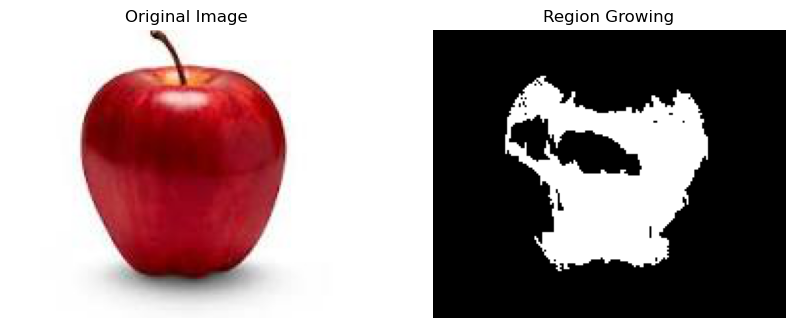

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("apple.jpg")
print(img.shape)
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# print(gray)
# Choose seed point INSIDE the object
seed = (100, 100)
print(seed)
# Get the pixel value automatically
seed_value = int(gray[seed[1], seed[0]])# row, column
print(seed_value)

#100 -20 100+20

# Threshold
threshold = 20

# Create output
region = np.zeros_like(gray)

# Queue
queue = [seed]

while queue:

    x, y = queue.pop(0)

    if region[y, x] == 1:
        continue

    # Compare pixel with seed value
    if abs(int(gray[y, x]) - seed_value) <= threshold:

        region[y, x] = 1

        # 4 neighbors
        neighbors = [
            (x-1, y),#l
            (x+1, y),#r,
            (x, y-1),#u,
            (x, y+1)#d
        ]
#Check if the neighbor is inside the image.
        for nx, ny in neighbors:

            if 0 <= nx < gray.shape[1] and \
               0 <= ny < gray.shape[0]:

                if region[ny, nx] == 0:
                    queue.append((nx, ny))

#Take each neighbor → check if it is inside the image → check if we haven't already used it → put it in the waiting list.
#Queue = waiting list of pixels to check.
# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(region, cmap="gray")
plt.title("Region Growing")
plt.axis("off")

plt.show()

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


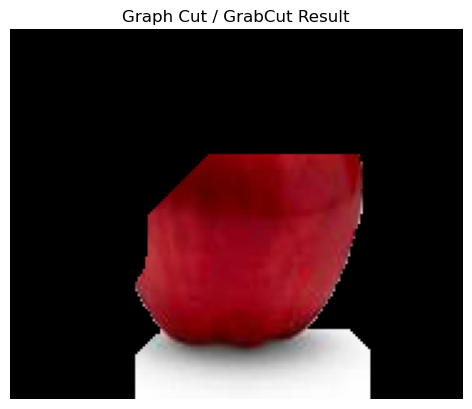

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("apple.jpg")

# Create mask
mask = np.zeros(img.shape[:2], np.uint8)

# Rectangle around the object
#(x, y, width, height)
rect = (50, 50, 300, 300)
#bgdModel → [ 65 spaces for background information ]
#fgdModel → [ 65 spaces for foreground information ]

# Background and foreground models
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Apply GrabCut
cv2.grabCut(
    img,
    mask,
    rect,
    bgdModel,
    fgdModel,
    5,# no f  iterations
    cv2.GC_INIT_WITH_RECT #I am giving you a rectangle as the initial information.
)

# Create final mask
result_mask = np.where(
    (mask == 2) | (mask == 0),
    0,
    1
).astype("uint8")
print(result_mask)

# Get foreground
result = img * result_mask[:, :, np.newaxis]

# Image:       (300, 400, 3)
# Mask:        (300, 400, 1)

# Display
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Graph Cut / GrabCut Result")
plt.axis("off")
plt.show()

# | Value | Meaning                 |
# | ----- | ----------------------- |
# | `0`   | **Definite background** |
# | `1`   | **Definite foreground** |
# | `2`   | **Probable background** |
# | `3`   | **Probable foreground** |
# Is this pixel definite background OR probable background?

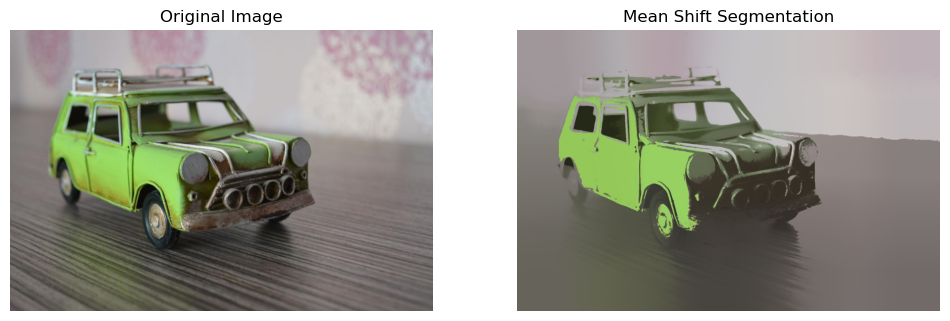

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("left.jpg")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mean Shift segmentation
segmented = cv2.pyrMeanShiftFiltering(img, sp=120, sr=60)

# Convert result to RGB
segmented_rgb = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_rgb)
plt.title("Mean Shift Segmentation")
plt.axis("off")

plt.show()

In [2]:
import cv2
import numpy as np
# Read image
img = cv2.imread("apple.jpg")
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Create initial labels
# 0 = Background
# 1 = Foreground
labels = np.zeros(gray.shape, dtype=np.uint8)
# Simple initial classification
# Bright pixels = foreground
labels[gray > 150] = 1
# MRF-like neighbour checking
for iteration in range(5):
    new_labels = labels.copy()
    for i in range(1, gray.shape[0] - 1):
        for j in range(1, gray.shape[1] - 1):
            # Current pixel
            pixel = gray[i, j]
            # Four neighbours
            top = labels[i-1, j]
            bottom = labels[i+1, j]
            left = labels[i, j-1]
            right = labels[i, j+1]
            # Count foreground neighbours
            foreground_count = (
                top + bottom + left + right
            )
            # Decide label
            if foreground_count >= 3:
                new_labels[i, j] = 1
            elif foreground_count <= 1:
                new_labels[i, j] = 0
    labels = new_labels
# Convert labels into image
result = labels * 255
cv2.imshow("Original", img)
cv2.imshow("MRF Segmentation", result)
cv2.waitKey(0)
cv2.destroyAllWindows()


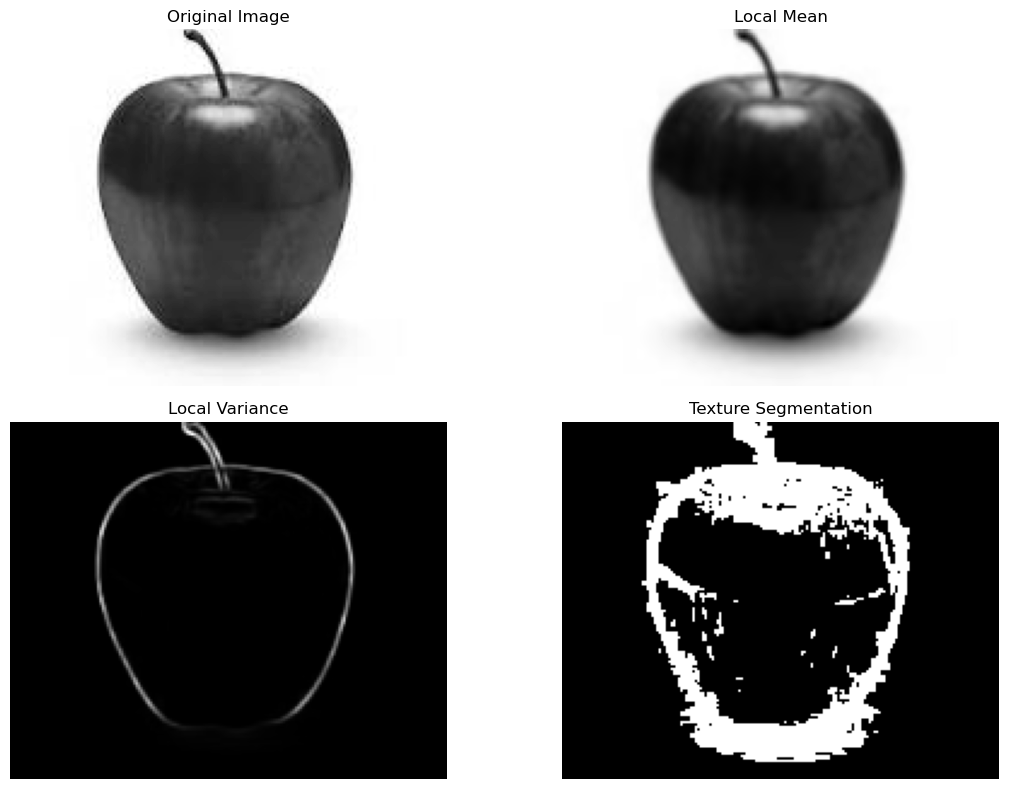

In [4]:
#texture segmention
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read image in grayscale
img = cv2.imread("apple.jpg", 0)

# 2. Convert image to float
img = img.astype(np.float32)

# 3. Calculate local mean using 3 × 3 window
mean = cv2.blur(img, (3, 3))

# 4. Calculate mean of squared pixels
mean_square = cv2.blur(img * img, (3, 3))

# 5. Calculate local variance
variance = mean_square - (mean * mean)

# 6. Normalize variance for display
variance_display = cv2.normalize(
    variance,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)
#None:  destination/output array is not specified. OpenCV automatically 
#creates the output array and returns it. fior texture segmentastion
# # 7. Texture segmentation
segmented = np.zeros_like(variance_display)
segmented[variance > 20] = 255

# 8. Display using Matplotlib
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mean, cmap="gray")
plt.title("Local Mean")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(variance_display, cmap="gray")
plt.title("Local Variance")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(segmented, cmap="gray")
plt.title("Texture Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()